# Computer Vison course. Seminar 03: Debayering and convolution implementation

## Bayer filter

The raw images coming from the camera are bayerized. They are represented as a two-dimensional array, where individual pixels encode the intensity of blue, green, and red colors.

![Bayer filter](https://github.com/alexmelekhin/cv_course_2023/blob/main/seminars/seminar_01/data/bayer.jpeg?raw=1)

OpenCV allows you to convert such images into familiar three-channel images. This process is called debayerization or demosaicing.

### Question 1

- Why are there 2 times more green pixels on the Bayer filter than blue or red ones?

Answer:

### Exercise 1: Bayerization

Convert the RGB image to a bayered image like the one above (in BGGR format), dividing the three channels into four contiguous pixels

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
!wget https://raw.githubusercontent.com/alexmelekhin/cv_course_2023/293bae2c70ca55f4938d2c8226869a360b1ac4b2/seminars/seminar_01/data/Lenna_test_image.jpeg

--2024-10-22 03:20:10--  https://raw.githubusercontent.com/alexmelekhin/cv_course_2023/293bae2c70ca55f4938d2c8226869a360b1ac4b2/seminars/seminar_01/data/Lenna_test_image.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 107478 (105K) [image/jpeg]
Saving to: ‘Lenna_test_image.jpeg’

Lenna_test_image.jp 100%[===================>] 104.96K  --.-KB/s    in 0.03s   

2024-10-22 03:20:10 (3.28 MB/s) - ‘Lenna_test_image.jpeg’ saved [107478/107478]



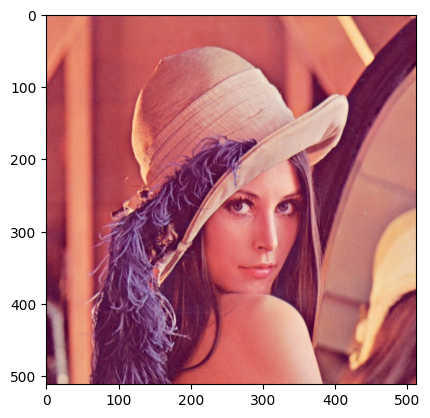

In [ ]:
img = cv2.imread("Lenna_test_image.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [ ]:
def rgb_to_bayer(img_rgb: np.ndarray) -> np.ndarray:
    H, W = img_rgb.shape[0], img_rgb.shape[1]
    bayer_img = np.zeros((H, W))

    # your code here
    bayer_img[0:H:2, 0:W:2] = img_rgb[0:H:2, 0:W:2, 2]
    bayer_img[1:H:2, 0:W:2] = img_rgb[1:H:2, 0:W:2, 1]
    bayer_img[0:H:2, 1:W:2] = img_rgb[0:H:2, 1:W:2, 1]
    bayer_img[1:H:2, 1:W:2] = img_rgb[1:H:2, 1:W:2, 0]

    return bayer_img.astype(np.uint8)

Let's look at a piece of the image close up:

In [ ]:
H, W, _ = img_rgb.shape

In [ ]:
img_bayer = rgb_to_bayer(img_rgb)

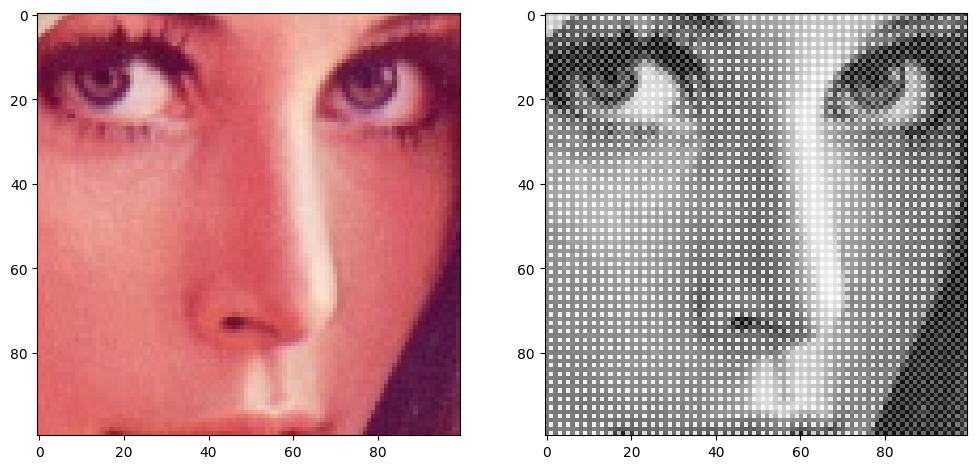

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb[250:350, 250:350])
axes[1].imshow(img_bayer[250:350, 250:350], cmap='Greys_r')

In [ ]:
img_bayer[1:H:2, 1:W:2].mean(), img_bayer[0:H:2, 0:W:2].mean()

(180.16445922851562, 105.43919372558594)

Let's get its bayerized version, the image should contain a characteristic mosaic pattern:

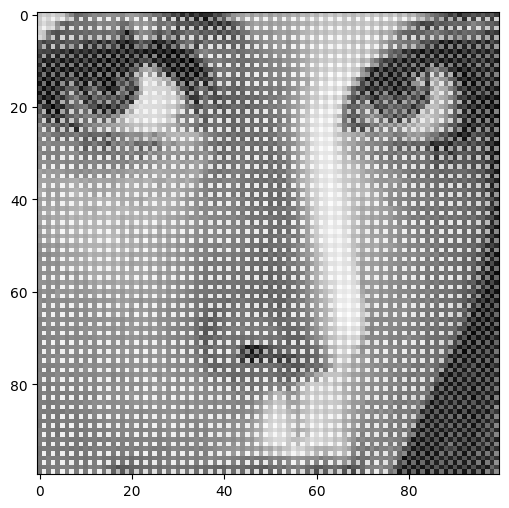

In [ ]:
img_bayer = rgb_to_bayer(img_rgb)
plt.figure(figsize=(6, 6))
plt.imshow(img_bayer[250:350, 250:350], cmap='Greys_r')

For debayering, you can use the function from OpenCV:

In [ ]:
[item for item in dir(cv2) if item.startswith('COLOR_')]

['COLOR_BAYER_BG2BGR',
 'COLOR_BAYER_BG2BGRA',
 'COLOR_BAYER_BG2BGR_EA',
 'COLOR_BAYER_BG2BGR_VNG',
 'COLOR_BAYER_BG2GRAY',
 'COLOR_BAYER_BG2RGB',
 'COLOR_BAYER_BG2RGBA',
 'COLOR_BAYER_BG2RGB_EA',
 'COLOR_BAYER_BG2RGB_VNG',
 'COLOR_BAYER_BGGR2BGR',
 'COLOR_BAYER_BGGR2BGRA',
 'COLOR_BAYER_BGGR2BGR_EA',
 'COLOR_BAYER_BGGR2BGR_VNG',
 'COLOR_BAYER_BGGR2GRAY',
 'COLOR_BAYER_BGGR2RGB',
 'COLOR_BAYER_BGGR2RGBA',
 'COLOR_BAYER_BGGR2RGB_EA',
 'COLOR_BAYER_BGGR2RGB_VNG',
 'COLOR_BAYER_GB2BGR',
 'COLOR_BAYER_GB2BGRA',
 'COLOR_BAYER_GB2BGR_EA',
 'COLOR_BAYER_GB2BGR_VNG',
 'COLOR_BAYER_GB2GRAY',
 'COLOR_BAYER_GB2RGB',
 'COLOR_BAYER_GB2RGBA',
 'COLOR_BAYER_GB2RGB_EA',
 'COLOR_BAYER_GB2RGB_VNG',
 'COLOR_BAYER_GBRG2BGR',
 'COLOR_BAYER_GBRG2BGRA',
 'COLOR_BAYER_GBRG2BGR_EA',
 'COLOR_BAYER_GBRG2BGR_VNG',
 'COLOR_BAYER_GBRG2GRAY',
 'COLOR_BAYER_GBRG2RGB',
 'COLOR_BAYER_GBRG2RGBA',
 'COLOR_BAYER_GBRG2RGB_EA',
 'COLOR_BAYER_GBRG2RGB_VNG',
 'COLOR_BAYER_GR2BGR',
 'COLOR_BAYER_GR2BGRA',
 'COLOR_BAYER_GR2BGR_

(512, 512, 3) (512, 512)


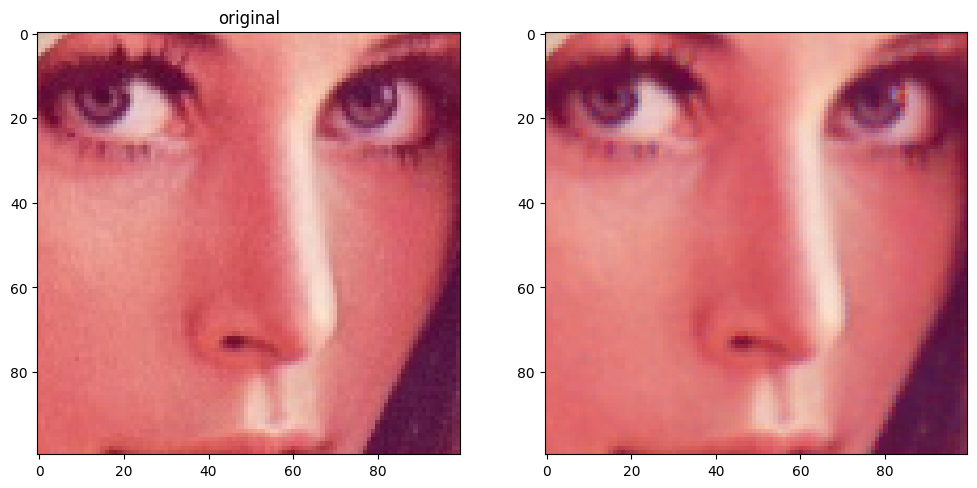

In [ ]:
img_debayer = cv2.cvtColor(img_bayer, cv2.COLOR_BayerBGGR2RGB)
print(img_debayer.shape, img_bayer.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb[250:350, 250:350])
axes[0].set_title('original')
axes[1].imshow(img_debayer[250:350, 250:350])
plt.show()

## Demosaicing

Such things are usually done with low level languages, but there is a project doing demosaicing in Python:

https://www.colour-science.org/colour-demosaicing/

In [ ]:
!pip install colour-demosaicing==0.2.4
!wget https://github.com/alexmelekhin/cv_course_2023/raw/293bae2c70ca55f4938d2c8226869a360b1ac4b2/seminars/seminar_02/data/lighthouse.exr

--2024-10-10 15:36:52--  https://github.com/alexmelekhin/cv_course_2023/raw/293bae2c70ca55f4938d2c8226869a360b1ac4b2/seminars/seminar_02/data/lighthouse.exr
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/alexmelekhin/cv_course_2023/293bae2c70ca55f4938d2c8226869a360b1ac4b2/seminars/seminar_02/data/lighthouse.exr [following]
--2024-10-10 15:36:52--  https://raw.githubusercontent.com/alexmelekhin/cv_course_2023/293bae2c70ca55f4938d2c8226869a360b1ac4b2/seminars/seminar_02/data/lighthouse.exr
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1684461 (1.6M) [application/octet-stream]
Saving to: ‘lighth

In [ ]:
from pathlib import Path

import colour

from colour_demosaicing import (
    demosaicing_CFA_Bayer_bilinear,
    demosaicing_CFA_Bayer_Malvar2004,
    demosaicing_CFA_Bayer_Menon2007,
    mosaicing_CFA_Bayer
)

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# allow cv2 to open .exr images
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"


rgb_img = cv2.imread("lighthouse.exr", cv2.IMREAD_UNCHANGED)[:, :, ::-1]
rgb_img = colour.cctf_encoding(rgb_img)
rgb_img.dtype

dtype('float64')

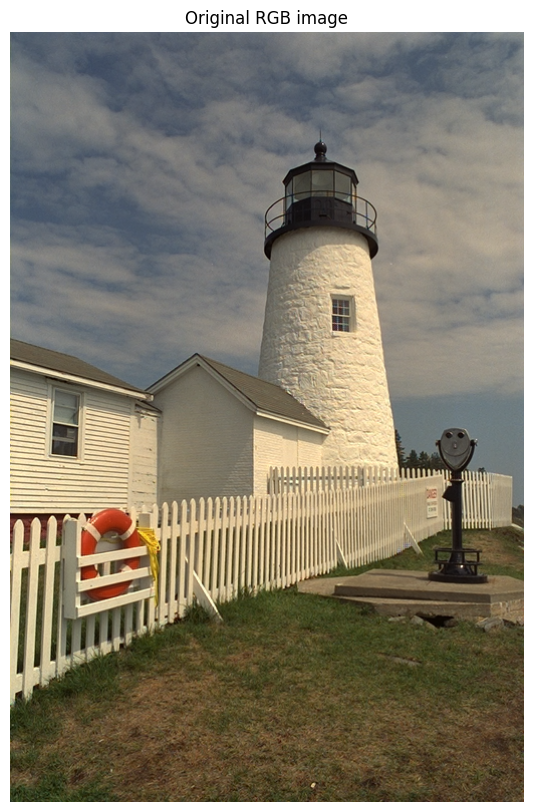

In [ ]:
plt.figure(figsize=[10, 10])
plt.axis("off")
plt.title("Original RGB image")
plt.imshow(rgb_img)

In [ ]:
mosaiced_image = mosaicing_CFA_Bayer(rgb_img, pattern="RGGB")
mosaiced_image.shape

(768, 512)

(768, 512)


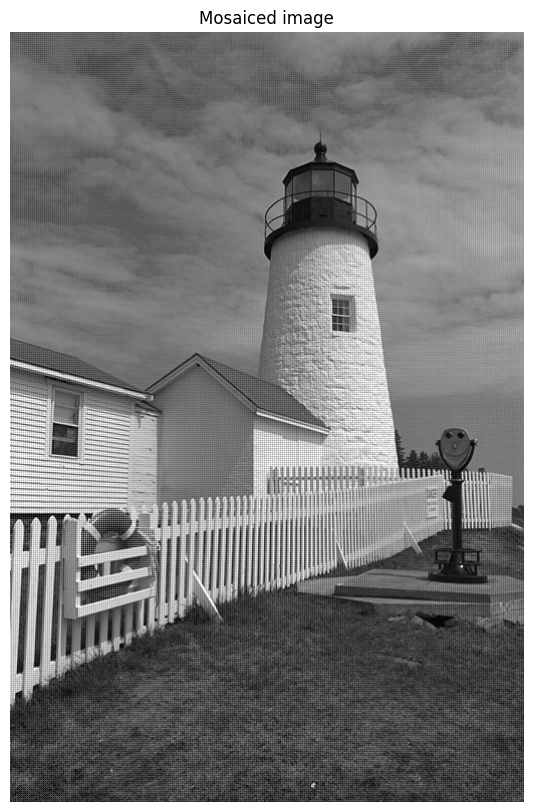

In [ ]:
plt.figure(figsize=[10, 10])
plt.axis("off")
plt.title("Mosaiced image")
plt.imshow(mosaiced_image, cmap="gray")
plt.show()

In [ ]:
def separate_chanel_rggb(img):
    new_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=img.dtype)
    new_img[0::2, 0::2, 0] = img[0::2, 0::2]  # R
    new_img[0::2, 1::2, 1] = img[0::2, 1::2]  # G1
    new_img[1::2, 0::2, 1] = img[0::2, 1::2]  # G2
    new_img[1::2, 1::2, 2] = img[0::2, 1::2]  # B
    return new_img

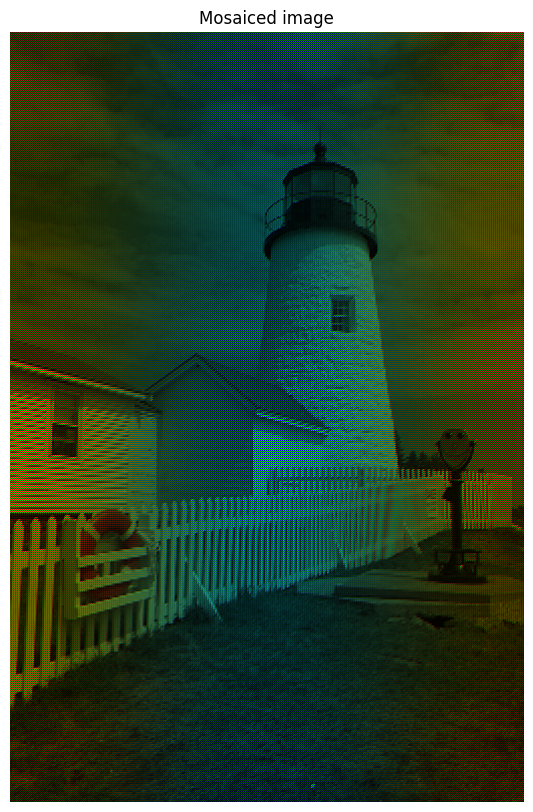

In [ ]:
plt.figure(figsize=[10, 10])
plt.axis("off")
plt.title("Mosaiced image")
plt.imshow(separate_chanel_rggb(mosaiced_image))

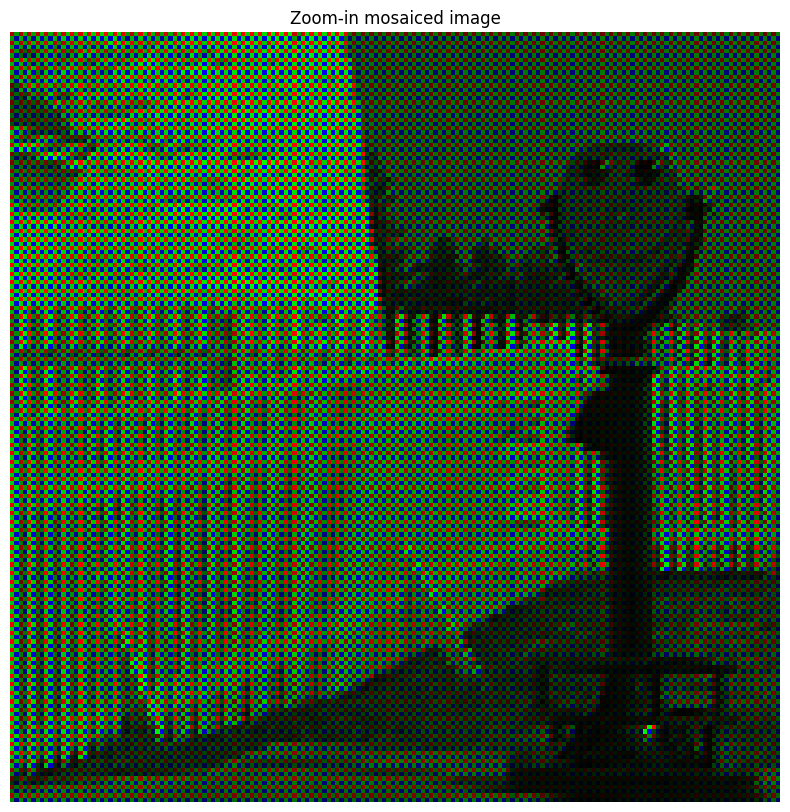

In [ ]:
plt.figure(figsize=[10, 10])
plt.axis("off")
plt.title("Zoom-in mosaiced image")
plt.imshow(separate_chanel_rggb(mosaiced_image)[370:550, 300:480])

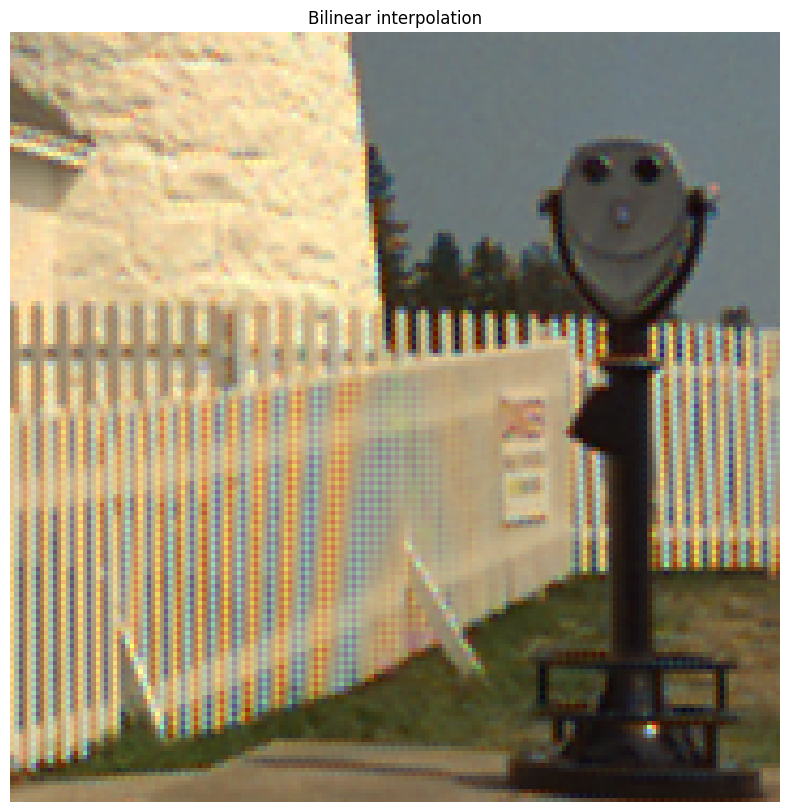

In [ ]:
plt.figure(figsize=[10, 10])
plt.axis("off")
plt.title("Bilinear interpolation")
plt.imshow(demosaicing_CFA_Bayer_bilinear(mosaiced_image)[370:550, 300:480])

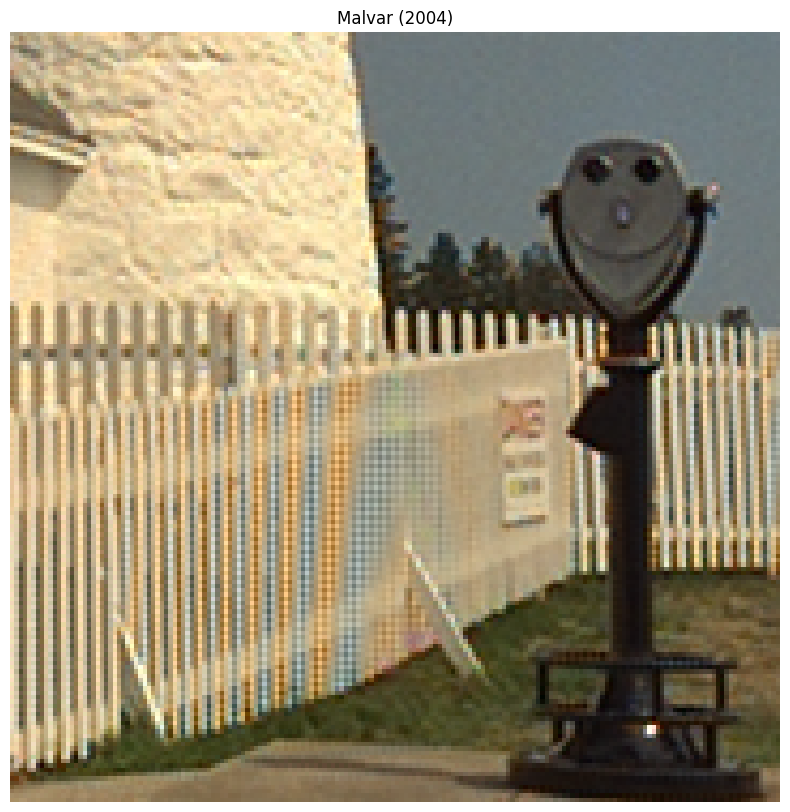

In [ ]:
plt.figure(figsize=[10, 10])
plt.axis("off")
plt.title("Malvar (2004)")
plt.imshow(demosaicing_CFA_Bayer_Malvar2004(mosaiced_image)[370:550, 300:480])

## Efficient convolution implementation

What is the algorithm for a convolution operation?

Let's implement strightforward mathematical algorithm.

In [ ]:
from time import time

from torch import nn
import torch
from tqdm import tqdm

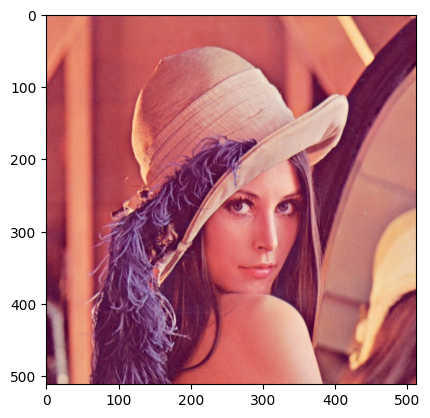

In [ ]:
lena_bgr = cv2.imread("Lenna_test_image.jpeg")
lena = cv2.cvtColor(lena_bgr, cv2.COLOR_BGR2RGB)
lena_red = lena[..., 0]

plt.imshow(lena)

In [ ]:
input_size = lena.shape[0]

conv = nn.Conv2d(1, 1, 2)
ip = torch.randint(low=0, high=10, size=(1, 1, input_size, input_size),  dtype=torch.float32)
conv.weight = nn.Parameter(torch.randint(low=0, high=10, size=(1, 1, 2, 2),  dtype=torch.float32))

ip_np = ip.numpy().reshape(-1, ip.shape[-1])
kernel_np = conv.weight.detach().squeeze().numpy()
bias_np = conv.bias.detach().squeeze().numpy()

In [ ]:
def conv_2d(kernel, bias, x):
    kernel_shape = kernel.shape[0]
    output_shape = x.shape[0] - kernel_shape + 1
    result = np.zeros((output_shape, output_shape))

    for row in range(x.shape[0] - 1):
        for col in range(x.shape[1] - 1):
            window = x[row: row + kernel_shape, col: col + kernel_shape]
            result[row, col] = np.sum(np.multiply(kernel, window))

    return result + bias

In [ ]:
%%timeit
conv_2d(kernel_np, bias_np, lena[..., 0])

2.1 s ± 338 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
def naive_im2col(x, kernel):
    kernel_shape = kernel.shape[0]
    rows = []

    # Assuming Padding = 0, stride = 1
    for row in range(x.shape[0] - 1):
        for col in range(x.shape[1] - 1):
            window = x[row: row + kernel_shape, col: col + kernel_shape]
            rows.append(window.flatten())
    return np.transpose(np.array(rows))

In [ ]:
%%timeit

flat_kernel = kernel_np.flatten()
res = np.dot(flat_kernel, naive_im2col(ip_np, kernel_np)) + bias_np

566 ms ± 20.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Next we will need to retrieve values at one run, for this we need a special function \
https://scikit-image.org/docs/stable/api/skimage.util.html#skimage.util.view_as_windows

In [ ]:
from skimage.util.shape import view_as_windows

In [ ]:
arr = np.arange(4*4).reshape(4,4)
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [ ]:
window_shape = (2, 2)
widows = view_as_windows(arr, window_shape)
widows.shape

(3, 3, 2, 2)

In [ ]:
widows

array([[[[ 0,  1],
         [ 4,  5]],

        [[ 1,  2],
         [ 5,  6]],

        [[ 2,  3],
         [ 6,  7]]],


       [[[ 4,  5],
         [ 8,  9]],

        [[ 5,  6],
         [ 9, 10]],

        [[ 6,  7],
         [10, 11]]],


       [[[ 8,  9],
         [12, 13]],

        [[ 9, 10],
         [13, 14]],

        [[10, 11],
         [14, 15]]]])

In [ ]:
widows.reshape(9, 4)

array([[ 0,  1,  4,  5],
       [ 1,  2,  5,  6],
       [ 2,  3,  6,  7],
       [ 4,  5,  8,  9],
       [ 5,  6,  9, 10],
       [ 6,  7, 10, 11],
       [ 8,  9, 12, 13],
       [ 9, 10, 13, 14],
       [10, 11, 14, 15]])

In [ ]:
def memory_strided_im2col(x, kernel):
    output_shape = x.shape[0] - kernel.shape[0] + 1
    windows = view_as_windows(x, kernel.shape)
    return windows.reshape(output_shape*output_shape, kernel.shape[0]*2)

In [ ]:
flat_kernel.shape

(4,)

In [ ]:
ip_np.shape

(512, 512)

In [ ]:
memory_strided_im2col(ip_np, kernel_np).shape

(261121, 4)

In [ ]:
kernel_np.shape

(2, 2)

In [ ]:
%%timeit
flat_kernel = kernel_np.flatten()
res = np.dot(memory_strided_im2col(ip_np, kernel_np), flat_kernel) + bias_np

61 µs ± 13.6 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
naive_time_log = []
torch_time_log = []
strided_time_log = []
naive_im2col_time_log = []
MAX_INPUT_SIZE = 300
NUM_RUNS = 20
input_size_list = list(range(3, MAX_INPUT_SIZE, 5))

for input_size in tqdm(input_size_list):
    torch_time = np.zeros(NUM_RUNS)
    naive_time = np.zeros(NUM_RUNS)
    im2col_time = np.zeros(NUM_RUNS)
    strided_time = np.zeros(NUM_RUNS)
    for run in range(NUM_RUNS):
        conv = nn.Conv2d(1, 1, 2)
        ip = torch.randint(low=0, high=10, size=(
            1, 1, input_size, input_size),  dtype=torch.float32)
        conv.weight = nn.Parameter(torch.randint(
            low=0, high=10, size=(1, 1, 2, 2),  dtype=torch.float32))
        ip_np = ip.numpy().reshape(-1, ip.shape[-1])
        kernel_np = conv.weight.detach().squeeze().numpy()
        bias_np = conv.bias.detach().squeeze().numpy()

        start = time()
        naive_conv = conv_2d(kernel_np, bias_np, ip_np)
        naive_time[run] = time() - start

        start = time()
        np.dot(naive_im2col(ip_np, kernel_np), kernel_np.flatten()) + bias_np
        im2col_time[run]= time() - start

        start = time()
        torch_conv = conv(ip)
        torch_time[run] = time() - start

        print(memory_strided_im2col(ip_np, kernel_np).shape)
        start = time()
        np.dot(memory_strided_im2col(ip_np, kernel_np), kernel_np.flatten()) + bias_np
        strided_time[run]= time() - start

        break

    naive_time_log.append(naive_time.mean())
    torch_time_log.append(torch_time.mean())
    strided_time_log.append(strided_time.mean())
    naive_im2col_time_log.append(im2col_time.mean())

plt.plot(input_size_list, naive_time_log,
          label='Naive Conv 2D', color='red')
plt.plot(input_size_list, torch_time_log,
          label='PyTorch Conv 2D', color='blue')
plt.plot(input_size_list, naive_im2col_time_log,
          label='Im2Col Conv 2D', color='green')
plt.plot(input_size_list, strided_time_log,
          label='Mem Strided Im2Col Conv 2D', color='purple')
plt.xlabel('Size of Input (n x n)')
plt.ylabel('Execution Time (secs) - Log Scale')
plt.yscale("log")
plt.legend()
plt.show()

  2%|▏         | 1/60 [00:00<00:06,  8.46it/s]

(4, 4)
(49, 4)


ValueError: shapes (4,) and (49,4) not aligned: 4 (dim 0) != 49 (dim 0)